# Introduction

Dans de nombreux problèmes de vision par ordinateur, l’objectif classique consiste à attribuer une étiquette de classe à chaque image : « chat », « chien », « voiture », etc. Dans cette étude, nous adoptons un point de vue différent : plutôt que de prédire directement une classe, nous cherchons à apprendre un espace d’embedding dans lequel les images d’objets similaires sont proches les unes des autres, et les images d’objets différents sont éloignées. Autrement dit, nous voulons apprendre une représentation continue qui capture la notion de similarité visuelle.

Pour construire un tel espace, nous nous appuyons sur l’architecture des réseaux siamois. Un réseau siamois ne se contente pas de traiter une image isolée : il compare plusieurs entrées en parallèle (typiquement un triplet ancre–positive–négative) et apprend à rapprocher les paires pertinentes tout en repoussant les paires non pertinentes. Pour la fonction de coût nous utiliserons une triplet loss. Celle-ci se chargera de formaliser précisément cet objectif en imposant une marge entre la distance ancre–positive et la distance ancre–négative dans l’espace des embeddings.

Nous introduisons ensuite la KoLeo loss, une régularisation destinée à mieux répartir la séparation entre classes. Nous visualiserons ceci grâce à une projection sur un espace 2D. La particularité de la KoLeo loss est qu’elle est dépendante du contenu du batch. En effet, les loss classiques sont généralement définies comme une moyenne sur le batch d’objets qui, pris individuellement, ne « voient » pas les autres exemples présents dans la même itération. La KoLeo loss, au contraire, exploite la distribution conjointe des embeddings d’un batch pour encourager un remplissage plus uniforme de l’espace et pénaliser les régions trop denses. Cette dépendance forte au batch rend particulièrement intéressante l’étude de l’accumulation de gradient, qui modifie la taille de batch effective et donc le comportement de cette régularisation. Mais est-ce réellement problématique d’avoir une loss aussi dépendante du batch, et dans quelle mesure cela impacte-t-il concrètement l’entraînement et les résultats obtenus ? C'est ce que nous allons essayer de comprendre.

L’article est structuré en trois grandes parties. Nous commençons par présenter le cadre des réseaux siamois et le modèle utilisé, ainsi que la triplet loss et la manière dont les triplets sont construits et évalués. Nous introduisons ensuite la KoLeo loss, expliquons son origine et son intégration dans notre pipeline, avant de comparer les résultats obtenus avec et sans cette régularisation. Enfin, nous discutons le rôle de l’accumulation de gradient dans ce contexte, en mettant en évidence la dépendance de la KoLeo loss à la taille de batch et l’impact que cela peut avoir sur la qualité finale des embeddings.


## Le dataset utilisé

Pour entraîner et évaluer notre modèle, nous utilisons le jeu de données [CIFAR‑10](https://www.cs.toronto.edu/~kriz/cifar.html), un benchmark classique composé de 60 000 images couleur de petite taille (32×32 pixels) réparties en 10 classes équilibrées : avion, voiture, oiseau, chat, cerf, chien, grenouille, cheval, bateau et camion. Les images sont initialement séparées en 50 000 exemples d’entraînement et 10 000 exemples de test, mais dans notre cas nous utiliserons uniquement les données d'entrainement. 

Après téléchargement nous pouvons déjà remarquer que l'archive contient 6 fichiers binaires contenant les images: `data_batch_[1/2/3/4/5]` et `test_batch`. Nous utiliserons uniquement les fichiers commençant par data_batch.

In [33]:
import numpy as np
import pickle

def unpickle(file):
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

batch_1 = unpickle(f"../cifar-10-python/data_batch_1")
print(f"Clefs de data_batch : {batch_1.keys()}")

Clefs de data_batch : dict_keys([b'batch_label', b'labels', b'data', b'filenames'])


Les clefs qui nous intéressent sont donc `data` et `labels`. Quelles sont leur types ?

In [34]:
type(batch_1[b'data']), type(batch_1[b'labels'])

(numpy.ndarray, list)

Quelles sont leurs tailles ?

In [35]:
print(f"Taille de data : {batch_1[b'data'].shape}, Taille de labels : {len(batch_1[b'labels'])}")

Taille de data : (10000, 3072), Taille de labels : 10000


Première particularité : la taille de la clef `data`. Chaque batch contient un tableau NumPy de forme `(10000, 3072)` : les 10 000 lignes correspondent aux images du batch, et les 3 072 colonnes à tous les pixels d’une image "aplatie" en un seul vecteur. En effet, une image CIFAR‑10 a une résolution de 32×32 pixels et 3 canaux couleur (R, G, B), soit \(32 x 32 x 3 = 3072\) valeurs au total.

Autrement dit, chaque ligne de `data` représente une image, mais sous forme linéarisée. Pour pouvoir afficher ou traiter ces images avec des bibliothèques de vision (et les passer à un réseau de neurones), nous devrons réorganiser les pixels dans une forme plus naturelle : `(32, 32, 3)`.

Mais avant cela, lisons tous les autres fichiers.

In [36]:

data_batch = [unpickle(f"../cifar-10-python/data_batch_{i}") for i in range(1, 6)]
images = np.concatenate([data_batch[i][b'data'] for i in range(5)])
labels = np.concatenate([data_batch[i][b'labels'] for i in range(5)])

images = images.reshape((-1, 3, 32, 32)).transpose(0, 2, 3, 1)
images.shape

(50000, 32, 32, 3)

Nous avons donc bien 50 000 images de taille 32x32 en RGB. En voici quelques unes sélectionnées aléatoirement avec leur labels.

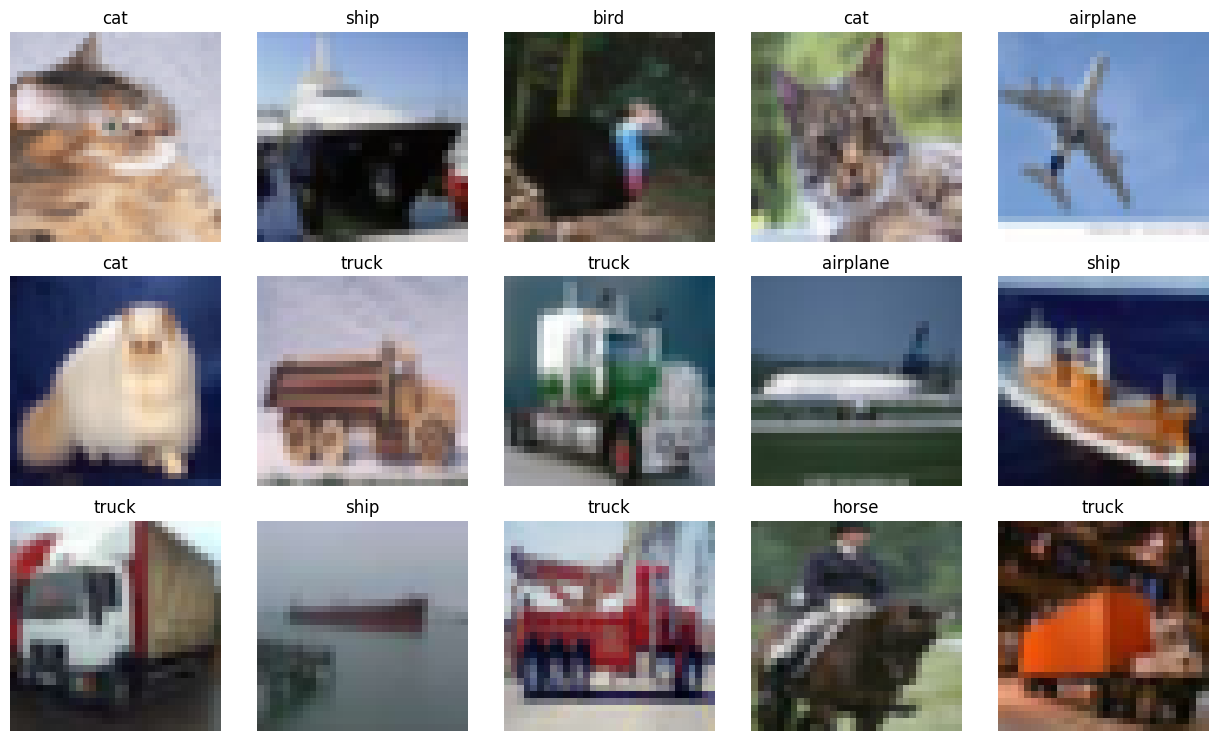

In [37]:
import matplotlib.pyplot as plt

label_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

n_rows, n_cols = 3, 5
indices = np.random.choice(len(images), n_rows * n_cols, replace=False)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.5 * n_cols, 2.5 * n_rows))

for ax, idx in zip(axes.ravel(), indices):
    ax.imshow(images[idx])
    label = label_names[labels[idx]]
    ax.set_title(label)
    ax.axis("off")

plt.tight_layout()
plt.show()


# Les réseaux siamois

## Qu'est-ce qu'un réseau siamois

Un réseau siamois est une architecture de réseau de neurones pensée non pas pour prédire directement une classe, mais pour comparer des exemples entre eux.

L’idée clé est la suivante : deux images que l’on considère comme « similaires » (par exemple deux chiens) doivent être proches l’une de l’autre dans cet espace, alors que deux images « différentes » (un chien et une voiture) doivent être éloignées. Pendant l’entraînement, on présente donc au modèle des paires ou des triplets d’images (ancre, positive, négative) et l’on ajuste les poids de façon à réduire la distance entre ancre et positive, tout en augmentant la distance entre ancre et négative.

Concrètement, dans le code, nous n’instancions qu’un seul réseau : nous lui passons tour à tour les images ancre, positive et négative, puis nous mettons à jour *une seule* fois les poids de ce modèle à partir de la loss calculée sur l’ensemble du triplet (nous aborderons la loss plus tard). Nous utiliserons ce modèle pour extraire les embeddings des images. Un *embedding* désigne ici la représentation vectorielle extraite par le réseau à partir d’une image, qui permet de comparer leur similarité dans un espace de dimension réduite. En pratique, presque n’importe quelle architecture de réseau de neurones (CNN, transformer, etc.) peut jouer ce rôle, à condition de produire un embedding en sortie.

Dans la suite, nous allons détailler le modèle utilisé pour produire ces embeddings, ainsi que la fonction de coût (triplet loss) qui formalise cette notion de similarité.

![Schéma d'un réseau siamois](siamese-scheme-french.png)

## VGG 11

VGG11 est une architecture de réseau de neurones convolutifs proposée en 2014 par une équipe de l’université d’Oxford (Simonyan et Zisserman). L’idée majeure de VGG est d’empiler de nombreux petits filtres convolutifs 3×3, séparés par des couches de pooling, plutôt que d’utiliser quelques grandes convolutions, ce qui permet d’augmenter la profondeur du réseau tout en gardant une structure très régulière.

VGG11 est l’une des variantes les plus simples de cette famille : onze couches organisées en blocs successifs, qui transforment une image RGB en un vecteur de caractéristiques de dimension fixe. Dans notre travail, nous partons de cette architecture pré‑entraînée sur ImageNet et nous l’adaptons pour produire des embeddings compacts adaptés à CIFAR‑10 et à l’apprentissage par triplets.

![VGG11](vgg11-model.png)

Mais voyons tout d'abord la taille du tenseur en sortie de VGG11.

In [38]:
import torch
from torchvision import models

vgg = models.vgg11(pretrained=False)

sample = images[0]                              
x = torch.from_numpy(sample).permute(2, 0, 1)
x = x.unsqueeze(0).float() / 255.0

with torch.no_grad():
    out = vgg(x)

print("Taille du tenseur en sortie de VGG11 :", out.shape)

Taille du tenseur en sortie de VGG11 : torch.Size([1, 1000])


La taille `(1, 1000)` signifie que, pour une image d’entrée, VGG11 renvoie un vecteur de 1 000 composantes. Ce nombre vient directement de la couche fully‑connected finale du modèle ImageNet d’origine : VGG11 a été conçu pour classer les images dans les 1 000 classes du challenge ImageNet, et sa dernière couche sort un vecteur de 1 000 probabilités, une probabilité pour chaque classe.

Dans notre cas, nous n’utiliserons pas ce vecteur. Nous utiliserons la sortie de la dernière couche de convolution de VGG donnée par `vgg.features`. Nous rajouterons juste une couche linéaire pour avoir un vecteur d'embedding de taille 128.

Quelle est la taille du tenseur juste après la dernière couche de convolution ?

In [39]:
with torch.no_grad():
    out = vgg.features(x)

print("Taille du tenseur en sortie de la dernière couche de convolution de VGG11 :", out.shape)

Taille du tenseur en sortie de la dernière couche de convolution de VGG11 : torch.Size([1, 512, 1, 1])


Nous remarquons que nous avons une taille de (512, 1, 1).
- 512 : le nombre de cartes de caractéristiques (features) produites par la dernière couche de convolution, donc 512 canaux différents décrivant l’image ;
- 1, 1 : la hauteur et la largeur spatiales, réduites à 1×1 par la succession de convolutions et de poolings, ce qui signifie que chaque canal résume toute l’image en un seul « neurone » (une valeur) avant de passer aux couches fully‑connected.

Nous aurons donc une taille en entrée de la couche linéaire de 512 x 1 x 1 = 512.

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class VGG11Embedding(nn.Module):
    def __init__(self, pretrained):
        super(VGG11Embedding, self).__init__()
        vgg = models.vgg11(pretrained=pretrained)
        self.features = vgg.features
        self.linear = nn.Linear(512, 128)
        
    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.linear(x)
        return x

Vérifions la taille en sortie de notre modèle :

In [41]:
vgg_embedding = VGG11Embedding(pretrained=False)

with torch.no_grad():
    out = vgg_embedding(x)

print("Taille du tenseur en sortie de notre modèle :", out.shape)

Taille du tenseur en sortie de notre modèle : torch.Size([1, 128])


Nous avons donc bien un vecteur d'embedding de taille 128.